## <img src="logo_UNSAM.jpg" align="right" width="300" height="300"> *Análisis y precesamiento de señales*  
<h3 style="font-weight: normal;">Alumno: Joaquín Rios</h3>
&nbsp;
&nbsp;

# |  Trabajo Semanal N°5

### | Introducción

&emsp; En este trabajo vamos a aplicar distintos métodos de estimación de la **densidad espectral de potencia (PSD)** sobre señales reales, con el objetivo de analizar su contenido frecuencial y caracterizar su ancho de banda. Para ello se trabajará con tres tipos de señales: un *electrocardiograma (ECG)*, un  *pletismografía (PPG)* y *una señal de audio* , obtenidas de los registros disponibles en el repositorio PDStestbench. A diferencia de los trabajos anteriores, donde se trabajó principalmente con señales jueguete y parámetros conocidos, en este caso analizaremos señales provenientes de mediciones reales, por lo que la estimación de su contenido espectral es fundamental para poder caracterizarlas.

&emsp; Para cada señal se estimará su PSD utilizando alguno de los siguientes métodos: periodograma ventaneado, método de Welch o método de Blackman-Tukey. El periodograma ventaneado se expresa como:

$$ \hat{S}_{xx}(f)=\frac{1}{NU}\left|\sum_{n=0}^{N-1}x[n]w[n]e^{-j2\pi fn}\right|^2 $$

donde $N$ es la cantidad de muestras del registro y $U$ es el factor de normalización asociado a la ventana, y donde básicamente estamos haciendo un promedio de todas las muestras implementando una ventana en la señal.

&emsp; Para el método de Welch, la señal se divide en $M$ segmentos de $N$ muestras, generalmente con solapamiento, calculándose un periodograma para cada segmento y promediándolos:

$$ \hat{S}_{W}(f)=\frac{1}{M}\sum_{i=1}^{M}\hat{S}_{i}(f) $$

donde $M$ es la cantidad de segmentos en los que se divide la señal y $N$ es la cantidad de muestras de cada segmento. En este caso se utilizará un solapamiento del $50$ %.

  Por otro lado, el método de Blackman-Tukey estima la PSD a partir de la autocorrelación de la señal:
  
$$ \hat{S}_{BT}(f)=\sum_{k=-M}^{M}\hat{R}_{xx}[k]w[k]e^{-j2\pi fk} $$

donde $M$ determina la cantidad de retardos de la autocorrelación que se utilizan.

### | Desarrollo Experimental
#### | Electrocardiograma
&emsp; Arrancamos analizando el *electrocardiograma (ECG)* eligiendo alguno de los métodos vistos anteriormente, en este caso usaremos el método de Welch, y para esto utilizaremos distintas longitudes de **L** para ver qué sucede, estas L serán proporcionales a la cantidad de muestras que tengamos, y se observarán 4 valores distintos en una misma figura. 
##### | Estimación de la Densidad Espectral de Potencia (DEP)

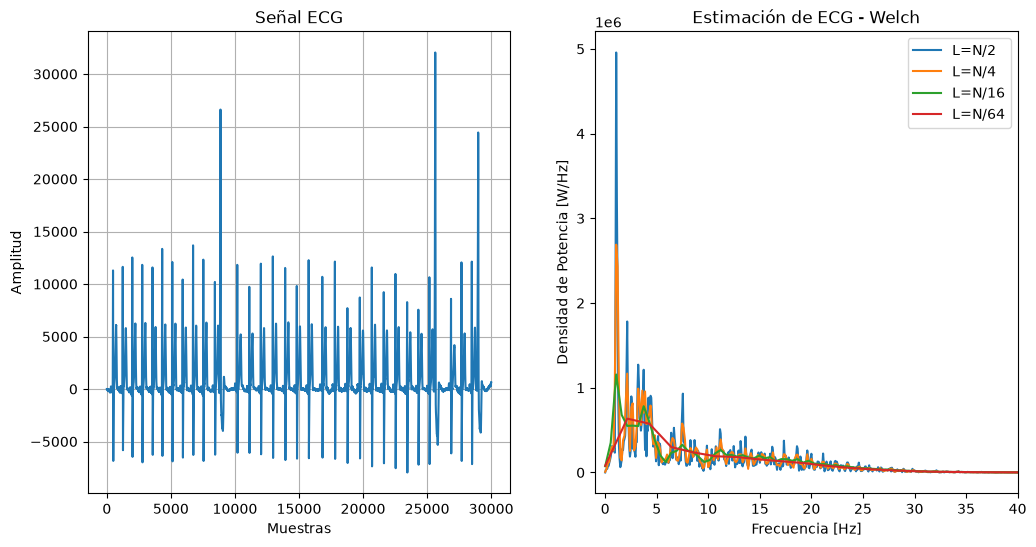

In [36]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import square, unit_impulse
from scipy.fft import fft,  fftfreq

import scipy.io as sio
from scipy.io.wavfile import write

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

#%%Definiciones
N = 1000
fs = 1000

##################
# Lectura de ECG #
##################

fs_ECG = 1000 # Hz

##################
## ECG sin ruido#
##################

ECG = np.load('ecg_sin_ruido.npy')

ax1.set_title('Señal ECG')
ax1.set_xlabel('Muestras')
ax1.set_ylabel('Amplitud')
ax1.plot(ECG)
ax1.grid(True)

NE = len(ECG)
#%%
frec, DEP_ECG_welch = signal.welch(ECG,fs=fs_ECG,nperseg=(max(1, NE//2))) #nperseg mide la longitud de cada periodograma para calcular la DEP 
frec2, DEP_ECG_welch2 = signal.welch(ECG, fs=fs_ECG, nperseg=max(1, NE//4))
frec3, DEP_ECG_welch3 = signal.welch(ECG, fs=fs_ECG, nperseg=max(1, NE//16))
frec4, DEP_ECG_welch4 = signal.welch(ECG, fs=fs_ECG, nperseg=max(1, NE//64))

ax2.set_title('Estimación de ECG - Welch')
ax2.set_xlabel('Frecuencia [Hz]')
ax2.set_ylabel('Densidad de Potencia [W/Hz]')
ax2.plot(frec,DEP_ECG_welch, label = "L=N/2")
ax2.plot(frec2,DEP_ECG_welch2, label = "L=N/4")
ax2.plot(frec3,DEP_ECG_welch3, label = "L=N/16")
ax2.plot(frec4,DEP_ECG_welch4, label = "L=N/64")
ax2.set_xlim(-1, 40)
ax2.legend()

plt.show()


&emsp; Primero hay que notar dos cuestiones importante, al estar promediando con un L cada vez más pequeño, por la relación $ Δf ≈  \frac{fs}{L}$ notamos que la resolución espectral empeora al bajar L. Por otro lado se acortó el eje X para que la señal se vea mejor en la figura, ya que luego de este valor la señal se mueve asintóticamente a 0.

&emsp; Analizando las 4 sesñales construidas a partir del ECG, notamos que, al aumentar la longitud de cada bloque de periodograma, el "pico" más alto de cada señal cae, esto se asocia directamente con el aumento del valor de resolución espectral, lo que provoca dos fenómenos diferentes, por un lado aumenta el sesgo de las muestras debido al ensanchamiento del lóbulo principal de la ventana utilizada, que en este caso en la $han$ por defecto en la función **signal.welch**, lo que induce un pico más bajo al estar tomando tal vez valores negativos incluso de la señal. En contraparte de este efecto, vemos como baja drásticamente la varianza de la señal, ya que esta es inversamente proporcional a $\frac{N}{L}$, la curva roja se la ve más suave. Parece que para representar bien la densidad espectral de potencia, a pesar de tener una varianza considerable, debemos mantener un L de bajo valor, ya que así podemos ver los armónicos fundamentales para representar bien la sañel original. Estos resultados se corroborarán de acuerdo a lo presentado en la siguente señal.

##### | Estimación del Ancho de Banda de la señal
&emsp; Para estimar el ancho de banda primero debemos establecer un criterio adecuado para esto, ya que sino podríamos tomar un ancho de banda para frecuencias que no aportan verdaderamente a la señal, por lo que se decidió que este debe contener el **99%** de la potencia de la señal.

In [37]:
df = frec[1] - frec[0]
potencia_acum = np.cumsum(DEP_ECG_welch) * df
limite = np.searchsorted(potencia_acum, 0.99 * potencia_acum[-1])
ancho_banda_99 = frec[limite]

print(f"Ancho de banda del 99 % de potencia con L ={NE/2}: {ancho_banda_99:.2f} Hz")

df = frec2[1] - frec2[0]
potencia_acum = np.cumsum(DEP_ECG_welch2) * df
limite = np.searchsorted(potencia_acum, 0.99 * potencia_acum[-1])
ancho_banda_99 = frec[limite]

print(f"Ancho de banda del 99 % de potencia con L ={NE/4}: {ancho_banda_99:.2f} Hz")

df = frec3[1] - frec3[0]
potencia_acum = np.cumsum(DEP_ECG_welch3) * df
limite = np.searchsorted(potencia_acum, 0.99 * potencia_acum[-1])
ancho_banda_99 = frec[limite]

print(f"Ancho de banda del 99 % de potencia con L ={NE/16}: {ancho_banda_99:.2f} Hz")

df = frec4[1] - frec4[0]
potencia_acum = np.cumsum(DEP_ECG_welch4) * df
limite = np.searchsorted(potencia_acum, 0.99 * potencia_acum[-1])
ancho_banda_99 = frec[limite]

print(f"Ancho de banda del 99 % de potencia con L ={NE/64}: {ancho_banda_99:.2f} Hz")


Ancho de banda del 99 % de potencia con L =15000.0: 31.33 Hz
Ancho de banda del 99 % de potencia con L =7500.0: 15.53 Hz
Ancho de banda del 99 % de potencia con L =1875.0: 4.00 Hz
Ancho de banda del 99 % de potencia con L =468.75: 1.00 Hz


&emsp; Con este resultado aparece algo que podría mejorar nuestro análisis, ya que un ancho de banda de 1 Hz y de 4 Hz no se ve consistente con lo que vemos en el gráfico frecuencial, por lo que consideramos estos resultados poco consistentes con un resultado lógico para el experimento. Luego de esto, creo que podemos decir que el resultado más consistente fue el que obtuvimos con un $L = 7500$, es decir con 7 bloques promediados con un **50 %** de solapamiento entre sí, esto ya que el gráfico de estimación parece ser coherente con lo analizado, y el ancho de banda también parece indicar un valor correcto para tener el **99 %** de la potencia de la señal.

&emsp; Además corroboramos que era una buena medida acortar el eje X a un valor de 40 Hz.

#### | Plestimografía
&emsp; Ahora analizaremos una *Plestimografía (PPG)* utilizando nuevamente el método de Welch, y para esto utilizaremos distintas longitudes de **L**, estas L serán proporcionales a la cantidad de muestras que tengamos, y se observarán 4 valores distintos en una misma figura, como en el caso anterior. 

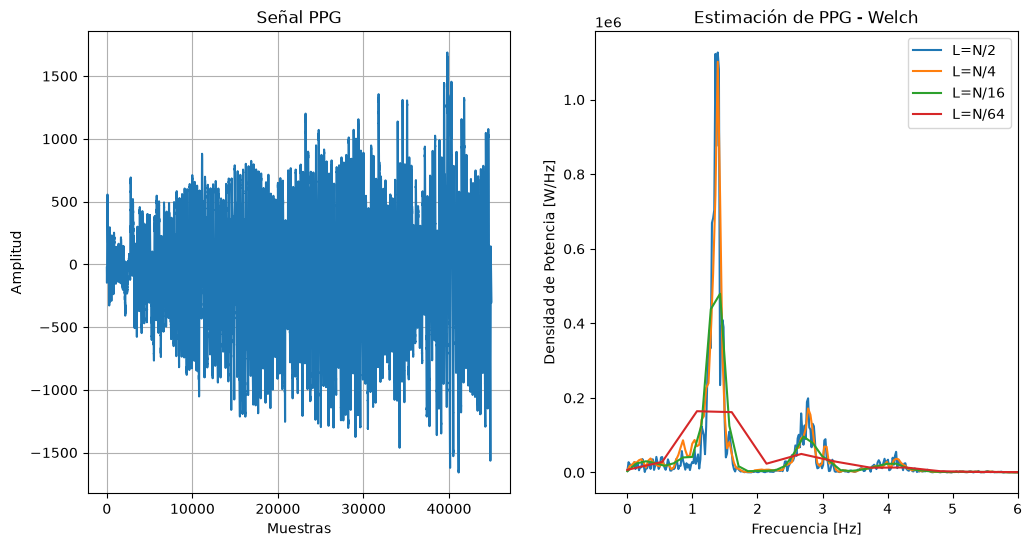

In [51]:
#%%

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

####################################
# Lectura de pletismografía (PPG)  #
####################################

fs_ppg = 400 # Hz

##################
## PPG sin ruido
##################

ppg = np.load('ppg_sin_ruido.npy')

ax1.set_title('Señal PPG')
ax1.set_xlabel('Muestras')
ax1.set_ylabel('Amplitud')
ax1.plot(ppg)
ax1.grid(True)

N = len(ppg)
#%%
frec, DEP_PPG_welch = signal.welch(ppg,fs=fs_ppg,nperseg=(max(1, N//2))) #nperseg mide la longitud de cada periodograma para calcular la DEP 
frec2, DEP_PPG_welch2 = signal.welch(ppg, fs=fs_ppg, nperseg=max(1, N//4))
frec3, DEP_PPG_welch3 = signal.welch(ppg, fs=fs_ppg, nperseg=max(1, N//16))
frec4, DEP_PPG_welch4 = signal.welch(ppg, fs=fs_ppg, nperseg=max(1, N//60))

ax2.set_title('Estimación de PPG - Welch')
ax2.set_xlabel('Frecuencia [Hz]')
ax2.set_ylabel('Densidad de Potencia [W/Hz]')
ax2.plot(frec,DEP_PPG_welch, label = "L=N/2")
ax2.plot(frec2,DEP_PPG_welch2, label = "L=N/4")
ax2.plot(frec3,DEP_PPG_welch3, label = "L=N/16")
ax2.plot(frec4,DEP_PPG_welch4, label = "L=N/64")
ax2.set_xlim(-0.5, 6)
ax2.legend()

plt.show()

&emsp; Pasamos a ver algo parecido a lo que vimos antes, aunque teniendo 3 (o tal vez 4) frecuencias que podemos notar como fundamentales para la PPG, Teniendo a su vez los mismos problemas que teníamos anteriormente, ya que a medida que bajamos el L, bajamos la varianza, pero aumenta el sezgo, por lo que esto pasa a ser un "tira y afloje" para ver qué valor nos conviene para representar mejor la señal. Por lo que podemos observar para un $L = \frac {N}{4}$ se observa que el sezgo prácticamente no baja, y baja considerablemente la varianza, por lo cuál es la que elegiría en este caso, o incluso un valor intermedio entre este y el que le sigue.

In [50]:
df = frec[1] - frec[0]
potencia_acum = np.cumsum(DEP_PPG_welch) * df
limite = np.searchsorted(potencia_acum, 0.99 * potencia_acum[-1])
ancho_banda_99 = frec[limite]

print(f"Ancho de banda del 99 % de potencia con L ={N/2}: {ancho_banda_99:.2f} Hz")

df = frec2[1] - frec2[0]
potencia_acum = np.cumsum(DEP_PPG_welch2) * df
limite = np.searchsorted(potencia_acum, 0.99 * potencia_acum[-1])
ancho_banda_99 = frec[limite]

print(f"Ancho de banda del 99 % de potencia con L ={N/4}: {ancho_banda_99:.2f} Hz")

df = frec3[1] - frec3[0]
potencia_acum = np.cumsum(DEP_PPG_welch3) * df
limite = np.searchsorted(potencia_acum, 0.99 * potencia_acum[-1])
ancho_banda_99 = frec[limite]

print(f"Ancho de banda del 99 % de potencia con L ={N/16}: {ancho_banda_99:.2f} Hz")

df = frec4[1] - frec4[0]
potencia_acum = np.cumsum(DEP_PPG_welch4) * df
limite = np.searchsorted(potencia_acum, 0.99 * potencia_acum[-1])
ancho_banda_99 = frec[limite]

print(f"Ancho de banda del 99 % de potencia con L ={N/64}: {ancho_banda_99:.2f} Hz")


Ancho de banda del 99 % de potencia con L =22459.5: 5.54 Hz
Ancho de banda del 99 % de potencia con L =11229.75: 2.71 Hz
Ancho de banda del 99 % de potencia con L =2807.4375: 0.68 Hz
Ancho de banda del 99 % de potencia con L =701.859375: 0.18 Hz


&emsp; Se ve cómo la elección del recorte del eje horizontal nuevamente se verifica al ver el ancho de banda del primer valor de L. Hay un problema con los últimos 2 valores, ya que parece que no representan bien el ancho de banda de la señal, por lo que nos seguimos quedando con los primeros dos valores.

#### | Audio de La Cucaracha
&emsp; Por último analizaremos el espectro de frecuencias de una señal de audio, más específicamente el audio de un silbido imitando el sonido de la canción de "la cucaracha", esta tiene ruido ambiente y una estructura que no necesariamente es periódica como podemos notarlo con las señales anteriores, por lo que este caso es distinto en este sentido, para esto tomaremos como base el estimador de *Blackman-tukey*, que primero calcula la autocorrelación de la señal y luego estima la densidad de potencia a partir de esta. Esto ya que parece para señales que no necesariamente son periódicas esto podría ser un mejor método para sus análisis. 

NameError: name '__file__' is not defined

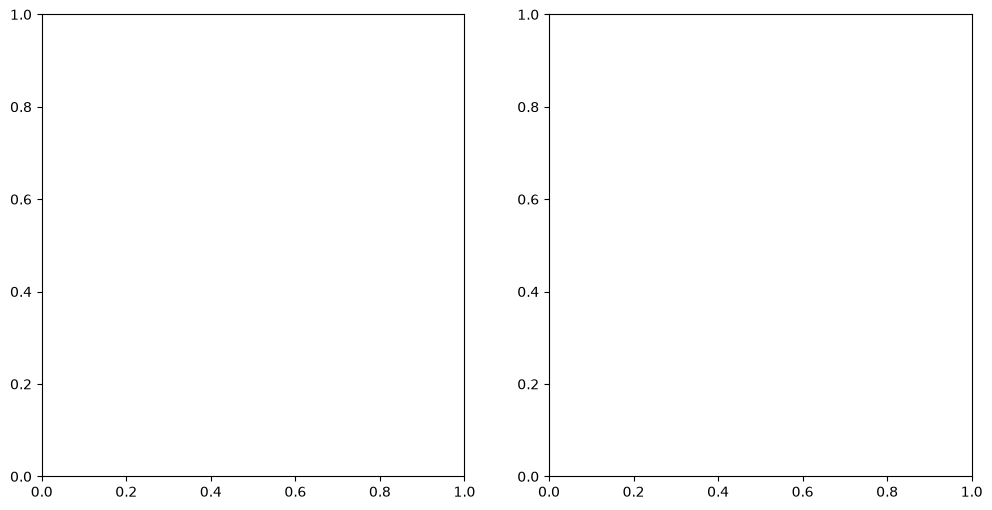

In [53]:
from scipy.io import wavfile
import sounddevice as sd

def blackman_tukey(x, fs_audio, M=None):
    x = np.asarray(x)

    # Convertir estéreo a mono, si hace falta
    if x.ndim == 2:
        x = x.mean(axis=1)

    x = x.astype(float)
    x -= np.mean(x)
    N = len(x)

    if N == 0:
        raise ValueError("El audio está vacío.")

    if M is None:
        M = max(1, N // 5)
    M = min(int(M), N)

    # Autocorrelación sesgada para retardos -(M-1) ... (M-1)
    r_completa = sig.correlate(x, x, mode="full", method="fft")
    r = r_completa[N - M:N + M - 1] / N

    # Ventana Blackman centrada en el retardo cero
    r *= sig.windows.blackman(2 * M - 1)

    # Reordenar retardos para calcular la FFT
    r_fft = np.zeros(N)
    r_fft[:M] = r[M - 1:]
    if M > 1:
        r_fft[-(M - 1):] = r[:M - 1]

    # DEP unilateral, en unidades de amplitud²/Hz
    Pxx = np.real(np.fft.rfft(r_fft)) / fs_audio
    if N % 2 == 0:
        Pxx[1:-1] *= 2
    else:
        Pxx[1:] *= 2

    frec = np.fft.rfftfreq(N, d=1 / fs_audio)
    return frec, np.maximum(Pxx, 0)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

fs_LCC, data = wavfile.read( Path(__file__).parent / "pdstestbench" / "la cucaracha.wav")

ax1.plot(data)
ax1.set_title("Audio de La Cucaracha")
ax1.set_xlabel("Muestras")
ax1.set_ylabel("Amplitud [cuentas]")
ax1.grid(True)

frec, DEP_AUDIO_BT = blackman_tukey(data, fs_LCC)

ax2.plot(frec, DEP_AUDIO_BT, label="Blackman–Tukey")
ax2.set_title("Estimación de audio - Blackman–Tukey")
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel("DEP [cuentas²/Hz]")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()